In [1]:
list.of.packages <- c("tidyverse","data.table","stargazer","sf","RColorBrewer","ggpubr")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=1200, message=FALSE, warning=TRUE)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


Les objets suivants sont masqués depuis ‘package:dplyr’:

    between, first, last


L'objet suivant est masqué depuis ‘package:purrr’:

    transpose



Please cite as: 


 Hlavac, Marek (2022).

# Malaria

In [2]:
sf_malaria <- st_read("./0_input/malaria/2011_Dist_malaria.gpkg")

Reading layer `districts' from data source 
  `/diskdata/cired/lepault/V6_Heat_India_30_20_10/0_input/malaria/2011_Dist_malaria.gpkg' 
  using driver `GPKG'
Simple feature collection with 641 features and 13 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 68.18625 ymin: 6.755953 xmax: 97.41529 ymax: 37.07827
Geodetic CRS:  WGS 84


In [3]:
head(sf_malaria,2)

Registered S3 method overwritten by 'geojsonsf':
  method        from   
  print.geojson geojson



,DISTRICT,ST_NM,ST_CEN_CD,DT_CEN_CD,censuscode,PF,ABER,API,SPR,AFI,SFR,death.Pv,death.Pf,geom
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<MULTIPOLYGON [°]>
1,Adilabad,Andhra Pradesh,28,1,532,71.43,13.07,0.01,0.01,0.01,0.01,0,0,MULTIPOLYGON (((78.84972 19...
2,Agra,Uttar Pradesh,9,15,146,2.44,3.18,0.02,0.05,0.00,0.00,0,0,MULTIPOLYGON (((78.19803 27...


In [4]:
theme_map <- function(...) {
  # On part du theme minimal, qui existe déjà
  # on retire juste les axes
  theme(
    title = element_text(size = 24),
    axis.line = element_blank(),
    axis.ticks = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_blank(),
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 16),
    legend.position="top",
    legend.key.size = unit(2, "cm"),
    axis.text.x = element_blank(),
    axis.text.y = element_blank(),
    panel.background = element_rect(fill = "aliceblue"),
  )
}

In [5]:
map_API <- ggplot(sf_malaria)+ 
                geom_sf(aes(fill=API))+
                scale_fill_gradientn(colours = rev(brewer.pal(8, "RdYlBu")),
                                    #limits = c(0, 40),
                                    breaks = c(0,5,10,15,20,25,30,35,40)
                                   )+
                theme_map()

In [6]:
sf_malaria_bin <- sf_malaria %>%
                    #st_drop_geometry()%>%
                    mutate(API_sup_1 = ifelse(API>1,1,ifelse(!is.na(API),0,NA)))
sprintf("%i x %i dataframe", nrow(sf_malaria_bin), ncol(sf_malaria_bin))
head(sf_malaria_bin,2)

[1] "641 x 15 dataframe"

,DISTRICT,ST_NM,ST_CEN_CD,DT_CEN_CD,censuscode,PF,ABER,API,SPR,AFI,SFR,death.Pv,death.Pf,geom,API_sup_1
,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<MULTIPOLYGON [°]>,<dbl>
1,Adilabad,Andhra Pradesh,28,1,532,71.43,13.07,0.01,0.01,0.01,0.01,0,0,MULTIPOLYGON (((78.84972 19...,0
2,Agra,Uttar Pradesh,9,15,146,2.44,3.18,0.02,0.05,0.00,0.00,0,0,MULTIPOLYGON (((78.19803 27...,0


In [7]:
map_binary <- ggplot(sf_malaria_bin)+ 
                    geom_sf(aes(fill=as.factor(API_sup_1)))+ 
                    labs(#title="Districts with high rates of malaria",
                         fill="API>1")+
                    scale_fill_manual(values=c("#00BFC4","#F8766D"),
                                      labels=c("No","Yes","Missing"),
                                      na.value="darkgrey")+
                    theme(title = element_text(size = 22),
                        axis.line = element_blank(),
                        axis.ticks = element_blank(),
                        axis.title.x = element_blank(),
                        axis.title.y = element_blank(),
                        legend.position="top",
                        legend.title = element_text(size = 20),
                        legend.text = element_text(size = 16),
                        legend.key.size = unit(1, "cm"),
                        axis.text.x = element_blank(),
                        axis.text.y = element_blank(),
                        panel.background = element_rect(fill = "aliceblue")
                  )

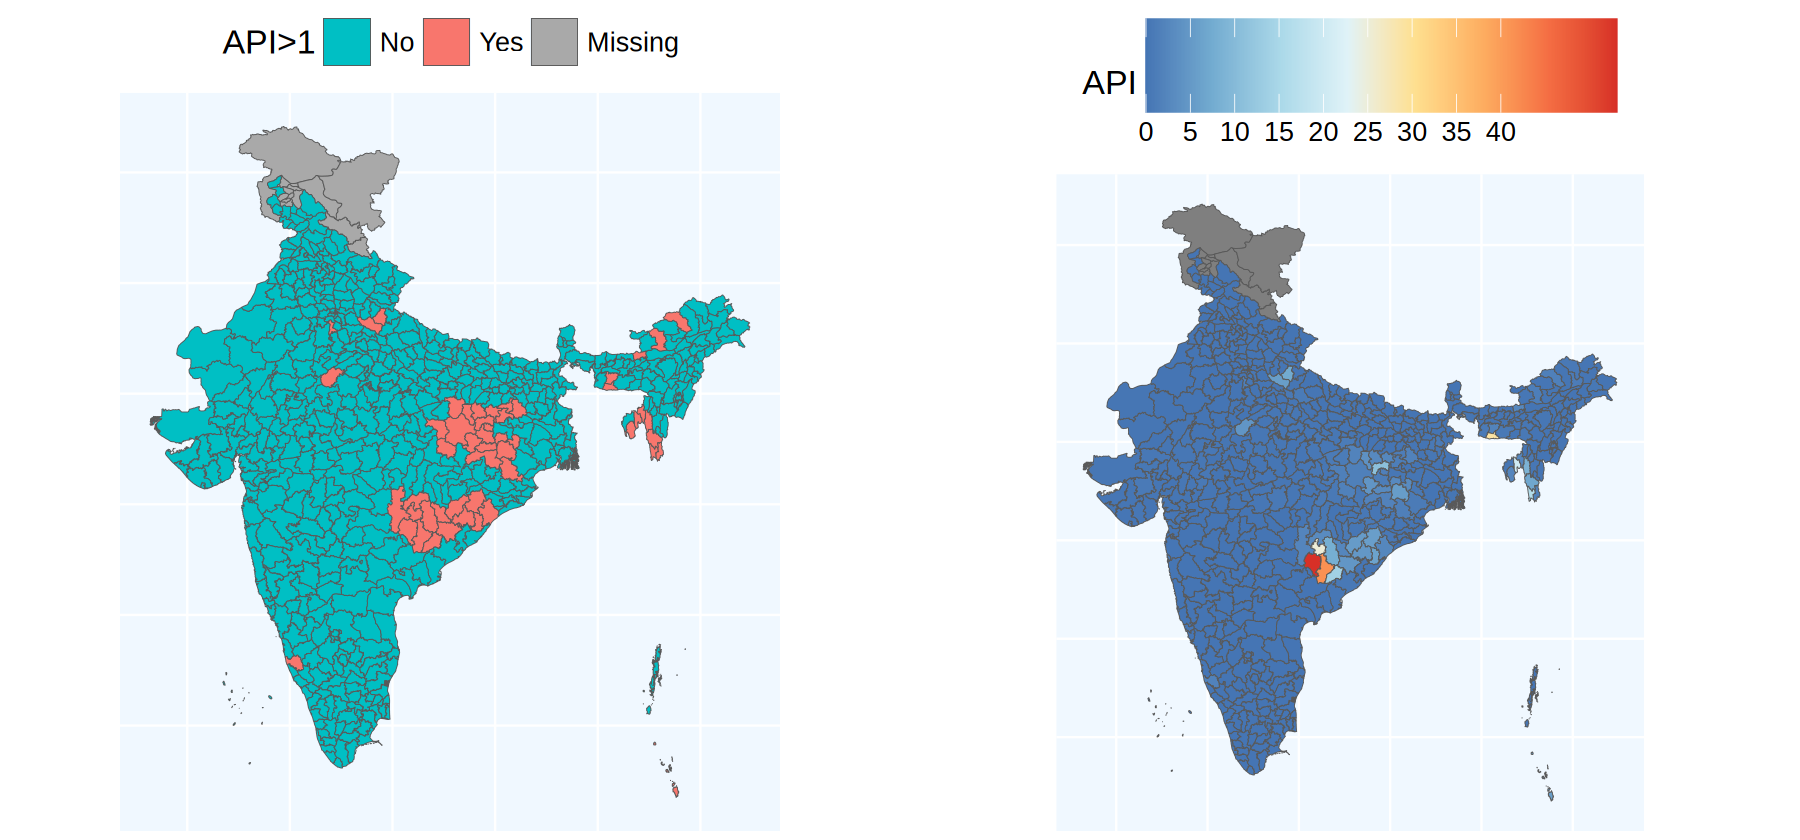

In [8]:
options(repr.plot.width=15, repr.plot.height=7, scipen=9999)

map_malaria <- ggarrange(map_binary,map_API,nrow=1,ncol=2)
map_malaria

In [9]:
ggsave("./3_output/img/map_malaria.png", width=15, height=7, map_malaria, dpi=60)